In [5]:
pip install pytrends plotly pandas

Note: you may need to restart the kernel to use updated packages.


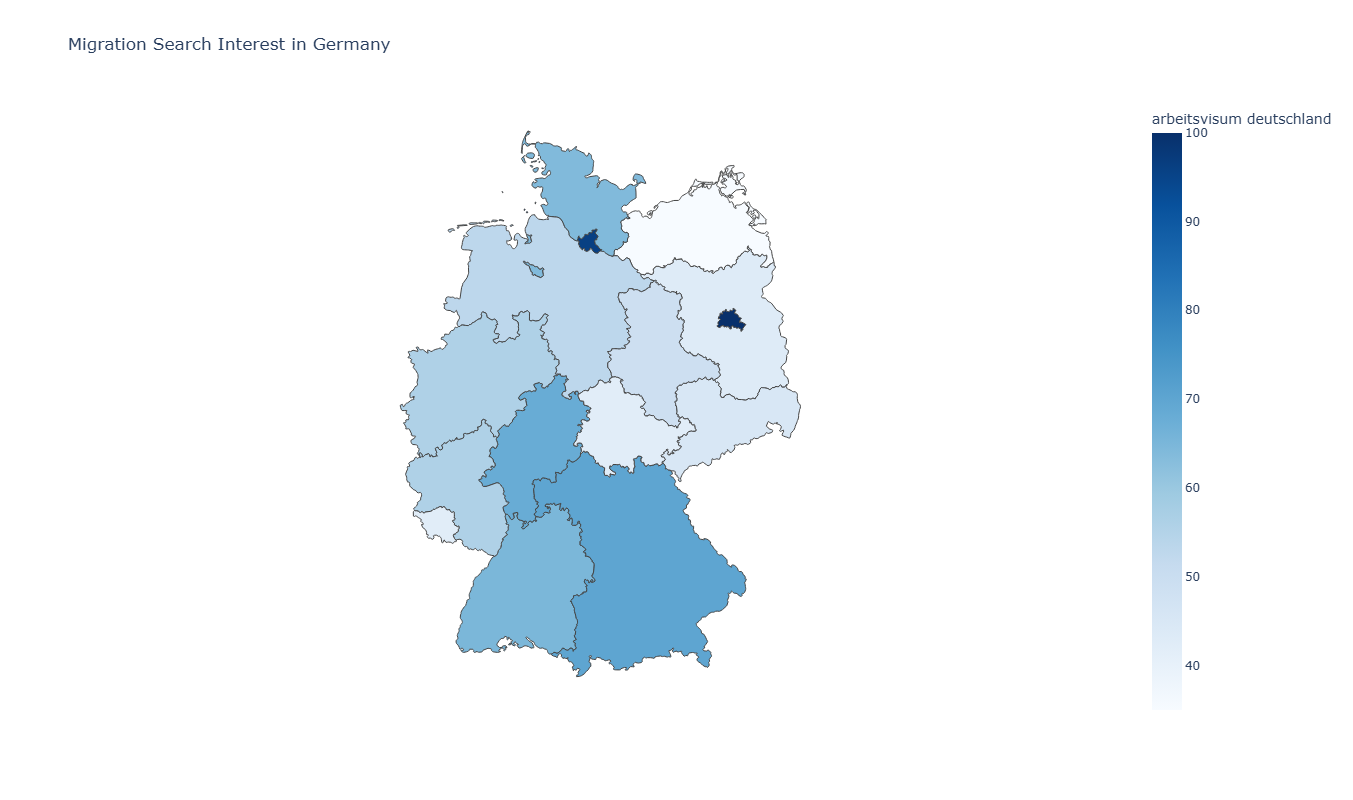

In [2]:
from pytrends.request import TrendReq
import plotly.express as px
import requests


# 1. Connect to Google Trends

pytrends = TrendReq(hl='de-DE', tz=360)


# 2. Build payload (trends data)

pytrends.build_payload(
    ["arbeitsvisum deutschland"],
    timeframe="today 5-y",
    geo="DE"
)


# 3. Get regional data

region_data = pytrends.interest_by_region(resolution='REGION', inc_low_vol=True)
region_data = region_data.reset_index()


# 4. Load Germany GeoJSON

geojson_url = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/germany.geojson"
geojson = requests.get(geojson_url).json()


# 5. Create Large Map

fig = px.choropleth(
    region_data,
    geojson=geojson,
    locations="geoName",
    featureidkey="properties.name",
    color="arbeitsvisum deutschland",
    scope="europe",
    title="Migration Search Interest in Germany",
    color_continuous_scale="Blues"
)

# Large size
fig.update_layout(
    width=1200,
    height=800
)

# Fit map to Germany
fig.update_geos(fitbounds="locations", visible=False)

fig.show()

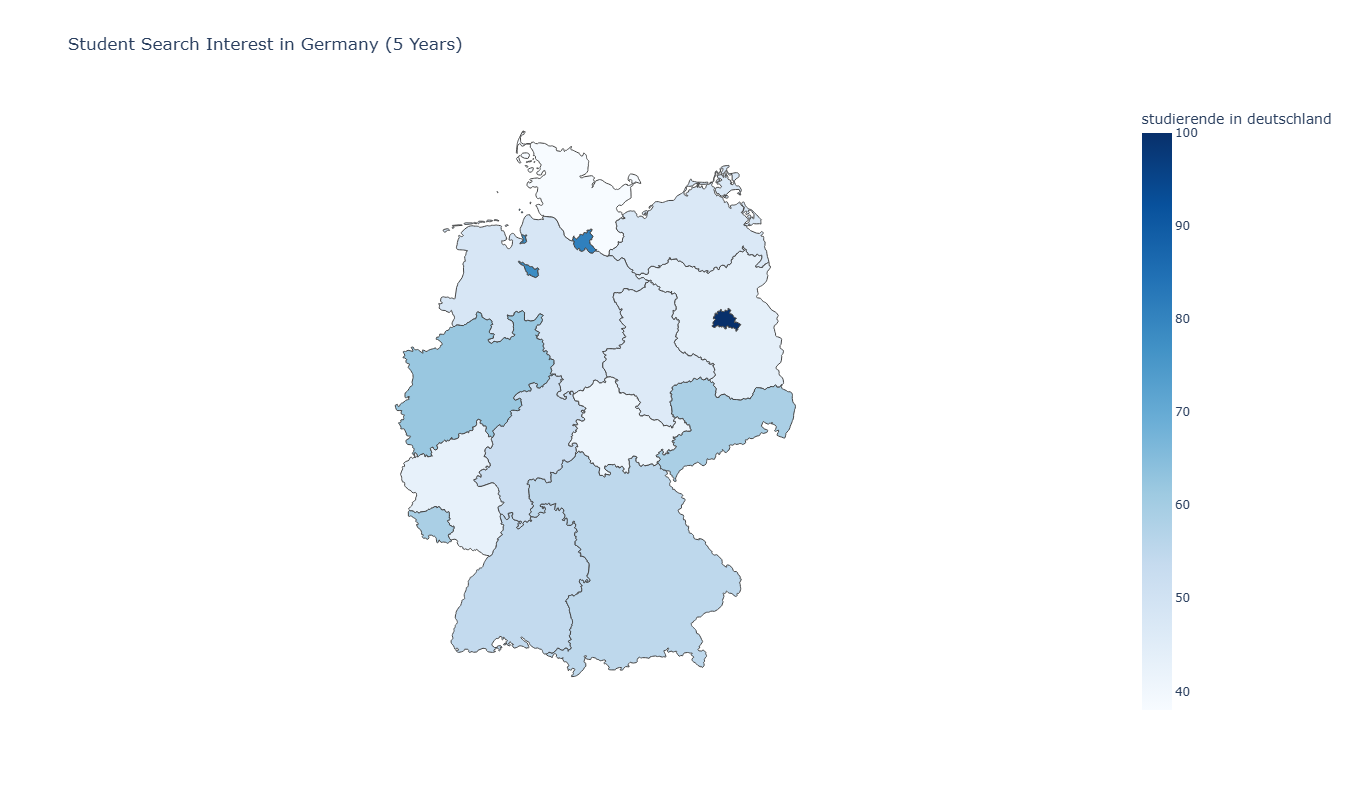

In [5]:
from pytrends.request import TrendReq
import plotly.express as px
import requests

# -----------------------------
# 1. Connect to Google Trends
# -----------------------------
pytrends = TrendReq(hl='de-DE', tz=360)

# -----------------------------
# 2. Student-related trends
# -----------------------------
pytrends.build_payload(
    ["studierende in deutschland"],
    timeframe="today 5-y",
    geo="DE"
)

# -----------------------------
# 3. Regional data
# -----------------------------
region_data = pytrends.interest_by_region(resolution='REGION', inc_low_vol=True)
region_data = region_data.reset_index()

# -----------------------------
# 4. Germany GeoJSON
# -----------------------------
geojson_url = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/germany.geojson"
geojson = requests.get(geojson_url).json()

# -----------------------------
# 5. Large Map
# -----------------------------
fig = px.choropleth(
    region_data,
    geojson=geojson,
    locations="geoName",
    featureidkey="properties.name",
    color="studierende in deutschland",
    scope="europe",
    title="Student Search Interest in Germany (5 Years)",
    color_continuous_scale="Blues"
)

fig.update_layout(
    width=1200,
    height=800
)

fig.update_geos(fitbounds="locations", visible=False)
fig.show()